# Spam Message Detection using LSTM.

In [ ]:
import pandas as pd

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
df = pd.read_csv("spam (1).csv",encoding = "Latin_1")

In [16]:
print(df.head(5))

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [17]:
df1 = df[["v1","v2"]]

In [18]:
df1.columns = ["Label","Text"]

In [19]:
df1["Label"] = df1["Label"].map({"ham":0,"spam":1})

In [20]:
df1.head()

,Label,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
print(df1.tail(5))

      Label                                               Text
5567      1  This is the 2nd time we have tried 2 contact u...
5568      0              Will Ì_ b going to esplanade fr home?
5569      0  Pity, * was in mood for that. So...any other s...
5570      0  The guy did some bitching but I acted like i'd...
5571      0                         Rofl. Its true to its name


In [22]:
print(df1.isnull())

      Label   Text
0     False  False
1     False  False
2     False  False
3     False  False
4     False  False
...     ...    ...
5567  False  False
5568  False  False
5569  False  False
5570  False  False
5571  False  False

[5572 rows x 2 columns]


In [23]:
print(df1.isnull().sum())

Label    0
Text     0
dtype: int64


In [24]:
x = df1["Text"]
y = df1["Label"]

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [28]:
tokens = Tokenizer(num_words=5000)

In [29]:
print(tokens)

In [30]:
tokens.fit_on_texts(x_train)

In [31]:
x_train_new = tokens.texts_to_sequences(x_train)

In [32]:
x_test_new = tokens.texts_to_sequences(x_test)

In [33]:
print(x_train_new[0])

[38, 30, 8, 5, 273, 1989, 81, 116, 26, 11, 1656, 322, 10, 53, 18, 299, 30, 349, 1990]


In [34]:
print(x_test_new[0])

[1366, 1578, 1432, 19, 19, 19, 38, 118, 1650, 19, 738, 4, 449, 3023, 35, 1285]


In [35]:
len(x_train_new)

4457

In [36]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [37]:
max_length = 50
x_train_padding = pad_sequences(x_train_new, maxlen = max_length)

In [38]:
x_test_padding = pad_sequences(x_test_new, maxlen = max_length)

In [39]:
print(x_train_padding[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0   38   30    8    5  273 1989   81  116   26   11 1656
  322   10   53   18  299   30  349 1990]


In [40]:
print(x_test_padding[0])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0 1366 1578 1432   19   19   19   38  118
 1650   19  738    4  449 3023   35 1285]


In [41]:
from tensorflow.keras.models import Sequential

In [42]:
from tensorflow.keras.layers import Dense ,LSTM,Embedding

In [43]:
model = Sequential()
model.add(Embedding(
       input_dim=5000,
       output_dim=32,
))

In [44]:
model.add(LSTM(32))
model.add(Dense(1,activation="sigmoid"))

In [45]:
model.compile(loss="binary_crossentropy",
              optimizer = "adam",
              metrics = ["accuracy"])

In [46]:
history = model.fit(x_train_padding,y_train,epochs=10,validation_split = 0.2,batch_size=32)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9142 - loss: 0.2630 - val_accuracy: 0.9765 - val_loss: 0.1098
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.9843 - loss: 0.0664 - val_accuracy: 0.9865 - val_loss: 0.0665
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9930 - loss: 0.0324 - val_accuracy: 0.9888 - val_loss: 0.0576
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9966 - loss: 0.0178 - val_accuracy: 0.9854 - val_loss: 0.0545
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9978 - loss: 0.0098 - val_accuracy: 0.9888 - val_loss: 0.0597
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9994 - loss: 0.0043 - val_accuracy: 0.9877 - val_loss: 0.0612
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9994 - loss: 0.0041 - val_accuracy: 0.9877 - val_loss: 0.0673
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accu

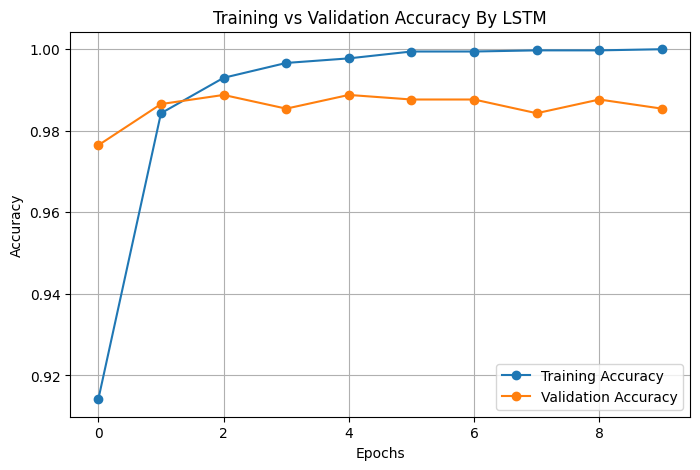

In [47]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'],marker = "o", label='Training Accuracy')
plt.plot(history.history['val_accuracy'],marker = "o", label='Validation Accuracy')

plt.title('Training vs Validation Accuracy By LSTM')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

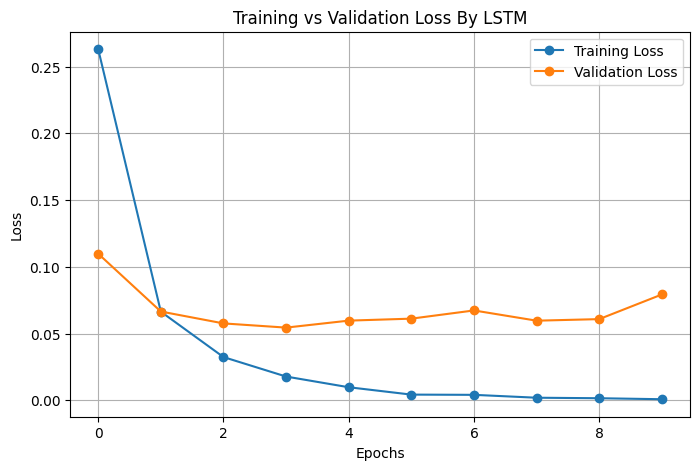

In [48]:
# Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],marker = "o", label='Training Loss')
plt.plot(history.history['val_loss'],marker = "o", label='Validation Loss')

plt.title('Training vs Validation Loss By LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
model.evaluate(x_test_padding,y_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9821 - loss: 0.0844


[0.08444817364215851, 0.9820627570152283]

In [50]:
from sklearn.metrics import accuracy_score, recall_score,precision_score, f1_score, confusion_matrix, classification_report

In [51]:
y_pred_prob = model.predict(x_test_padding)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [52]:
print(y_pred_prob)

[[9.9601400e-01]
 [2.4701966e-04]
 [9.8659402e-01]
 ...
 [2.0790927e-04]
 [1.9213223e-04]
 [9.9167746e-01]]


In [53]:
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

In [54]:
print(y_pred)

[1 0 1 ... 0 0 1]


In [55]:
accuracy = accuracy_score(y_test,y_pred)

In [56]:
print("Accuracy:",accuracy)

Accuracy: 0.9820627802690582


In [57]:
precision = precision_score(y_test,y_pred)

In [58]:
print("Precision:",precision)

Precision: 0.9779411764705882


In [59]:
recall = recall_score(y_test,y_pred)

In [60]:
print("Recall:",recall)

Recall: 0.8866666666666667


In [61]:
f1 = f1_score(y_test,y_pred)

In [62]:
print("F1:",f1)

F1: 0.9300699300699301


In [63]:
cm = confusion_matrix(y_test,y_pred)

In [64]:
print("cm",cm)

cm [[962   3]
 [ 17 133]]


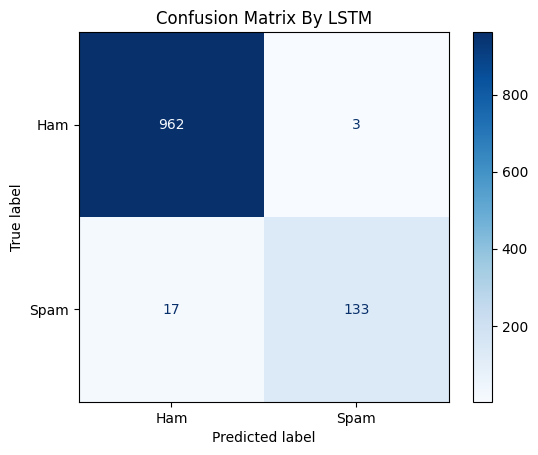

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot(cmap='Blues')
plt.title('Confusion Matrix By LSTM')
plt.show()

In [66]:
cr = classification_report(y_test,y_pred)

In [67]:
print("cr",cr)

cr               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [68]:
user_input = ["Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"]

In [69]:
user_input_token = tokens.texts_to_sequences(user_input)

In [70]:
print(user_input_token)

[[49, 435, 8, 19, 4, 734, 777, 2, 181, 1827, 1130, 612, 1828, 2217, 253, 2897, 69, 1827, 2, 1829, 2, 316, 435, 556, 932, 71, 403, 174, 653, 397, 2898]]


In [71]:
user_padding = pad_sequences(user_input_token,maxlen=max_length)

In [72]:
print(user_padding)

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0   49  435    8   19    4  734  777    2  181
  1827 1130  612 1828 2217  253 2897   69 1827    2 1829    2  316  435
   556  932   71  403  174  653  397 2898]]


In [73]:
prediction = model.predict(user_padding)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [74]:
print(prediction)

[[0.9983471]]


In [75]:
if prediction[0][0]>0.5:
  print("spam")
else:
  print("ham")

spam
